✅ Raw data loaded. Shape: (14640, 15)
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN             

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pranav\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Text cleaning done!
                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                          clean_text  
0                                               said  
1      plus youve added commercials experience tacky  
2       didnt today must mean need take another trip  
3  really aggressive blast obnoxious entertainmen...  
4                               really big bad thing  


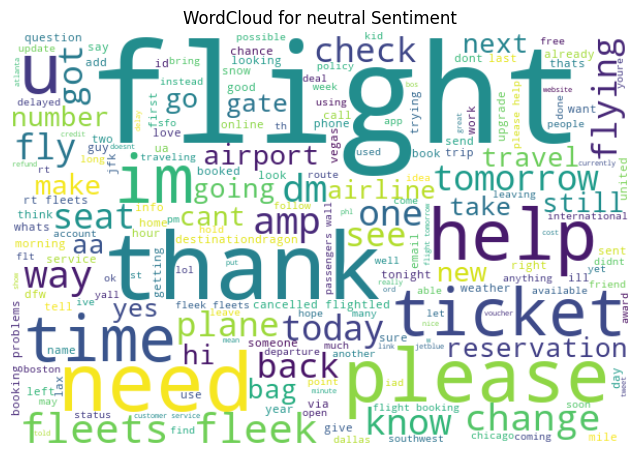

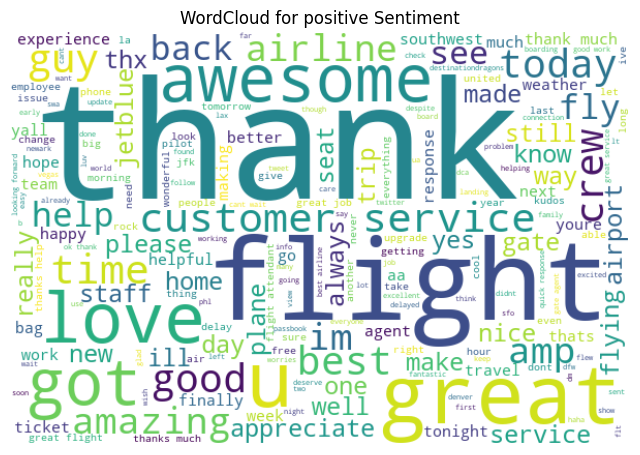

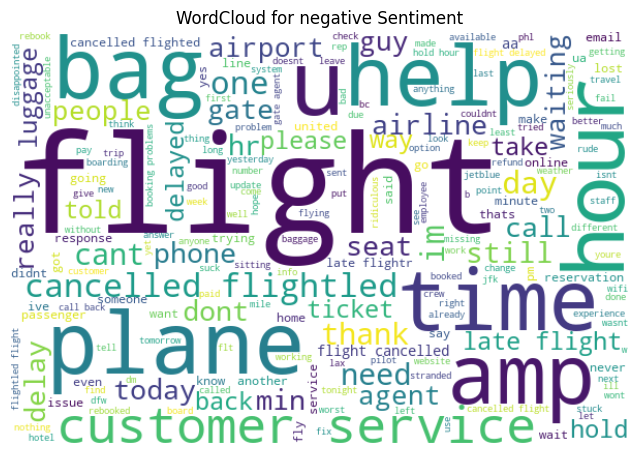

✅ Cleaned dataset saved at ../data/sentiment_tweets.csv
✅ Model Training Complete
Accuracy: 0.8002049180327869

Classification Report:
               precision    recall  f1-score   support

    negative       0.82      0.94      0.88      1889
     neutral       0.67      0.48      0.56       580
    positive       0.83      0.62      0.71       459

    accuracy                           0.80      2928
   macro avg       0.77      0.68      0.72      2928
weighted avg       0.79      0.80      0.79      2928

✅ Model & Vectorizer saved in ../models/


In [3]:
# 2_data_cleaning.ipynb

# -----------------------------
# 1. Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import re
import string
import os
import pickle
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# -----------------------------
# 2. Load Dataset
# -----------------------------
df = pd.read_csv("../data/Tweets.csv")

print("✅ Raw data loaded. Shape:", df.shape)
print(df.head())

# -----------------------------
# 3. Text Cleaning Function
# -----------------------------
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # remove URLs
    text = re.sub(r"@\w+|#", "", text)                   # remove mentions/hashtags
    text = re.sub(r"[^a-z\s]", "", text)                 # keep only alphabets
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

# -----------------------------
# 4. Apply Cleaning
# -----------------------------
df["clean_text"] = df["text"].apply(clean_text)

print("✅ Text cleaning done!")
print(df[["text", "clean_text"]].head())

# -----------------------------
# 5. WordCloud per Sentiment
# -----------------------------
for sentiment in df["airline_sentiment"].unique():
    text = " ".join(df[df["airline_sentiment"] == sentiment]["clean_text"].astype(str))
    wc = WordCloud(width=600, height=400, background_color="white").generate(text)
    plt.figure(figsize=(8,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud for {sentiment} Sentiment")
    plt.show()

# -----------------------------
# 6. Save Cleaned Data
# -----------------------------
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/sentiment_tweets.csv", index=False)
print("✅ Cleaned dataset saved at ../data/sentiment_tweets.csv")

# -----------------------------
# 7. Model Training (Baseline Logistic Regression)
# -----------------------------
X = df["clean_text"]
y = df["airline_sentiment"]

tfidf = TfidfVectorizer(max_features=5000)
X_vec = tfidf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("✅ Model Training Complete")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 8. Save Model & Vectorizer
# -----------------------------
os.makedirs("../models", exist_ok=True)

with open("../models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("../models/sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model & Vectorizer saved in ../models/")
